# Exploratory Data Analysis — Premier League 2025/26

This notebook explores the cleaned Premier League dataset.

The main objectives are:

- Analyze match results
- Analyze goal distributions
- Compare home and away performance
- Analyze team performance
- Study shooting statistics
- Investigate relationships between football statistics
- Identify interesting match-level patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/PremierLeague25_26_clean.csv")

# Convert Date back to datetime because CSV does not preserve pandas datetime types
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,2025-08-16,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,2025-08-16,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,2025-08-16,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,2025-08-16,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 380
Columns: 132


## 2. Feature Preparation for EDA

We create a few derived variables that make football analysis easier.

`TotalGoals` represents the total number of goals scored in a match.

`GoalDifference` represents the difference between home and away goals.

In [4]:
df["TotalGoals"] = df["FTHG"] + df["FTAG"]
df["GoalDifference"] = df["FTHG"] - df["FTAG"]
df[
    [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
        "FTR",
        "TotalGoals",
        "GoalDifference"
    ]
].head(10)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19700\3505112506.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["TotalGoals"] = df["FTHG"] + df["FTAG"]
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19700\3505112506.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["GoalDifference"] = df["FTHG"] - df["FTAG"]


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,TotalGoals,GoalDifference
0,2025-08-15,Liverpool,Bournemouth,4,2,H,6,2
1,2025-08-16,Aston Villa,Newcastle,0,0,D,0,0
2,2025-08-16,Brighton,Fulham,1,1,D,2,0
3,2025-08-16,Sunderland,West Ham,3,0,H,3,3
4,2025-08-16,Tottenham,Burnley,3,0,H,3,3
5,2025-08-16,Wolves,Man City,0,4,A,4,-4
6,2025-08-17,Chelsea,Crystal Palace,0,0,D,0,0
7,2025-08-17,Nott'm Forest,Brentford,3,1,H,4,2
8,2025-08-17,Man United,Arsenal,0,1,A,1,-1
9,2025-08-18,Leeds,Everton,1,0,H,1,1


## 3. Match Result Analysis

We first examine how the 380 matches were distributed between:

- Home wins
- Draws
- Away wins

The `FTR` column contains:

- `H` = Home win
- `D` = Draw
- `A` = Away win

In [5]:
result_counts = df["FTR"].value_counts()

result_counts

FTR
H    162
A    114
D    104
Name: count, dtype: int64

In [6]:
result_labels = {
    "H": "Home Win",
    "D": "Draw",
    "A": "Away Win"
}

result_counts_display = result_counts.rename(index=result_labels)

result_counts_display

FTR
Home Win    162
Away Win    114
Draw        104
Name: count, dtype: int64

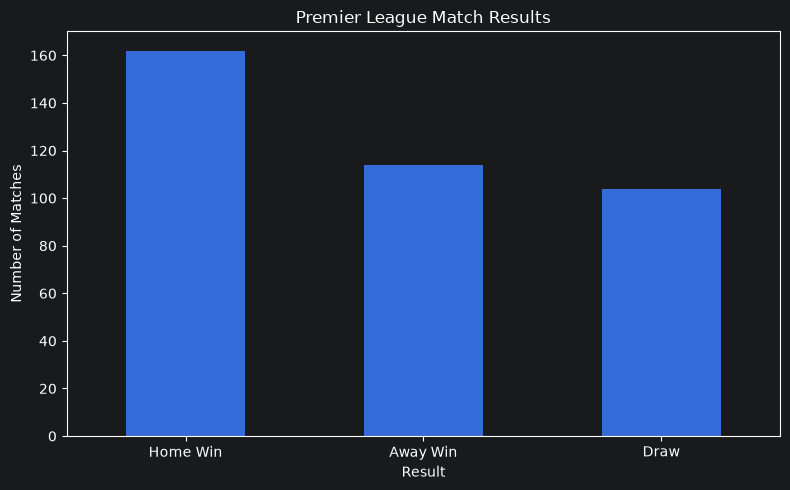

In [7]:
plt.figure(figsize=(8, 5))

result_counts_display.plot(kind="bar")

plt.title("Premier League Match Results")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. Match Result Percentages

Counts tell us the number of matches, while percentages make the distribution easier to compare.

In [8]:
result_percentage = (
    df["FTR"]
    .value_counts(normalize=True)
    .mul(100)
)

result_percentage_display = result_percentage.rename(index=result_labels)

result_percentage_display

FTR
Home Win    42.631579
Away Win    30.000000
Draw        27.368421
Name: proportion, dtype: float64

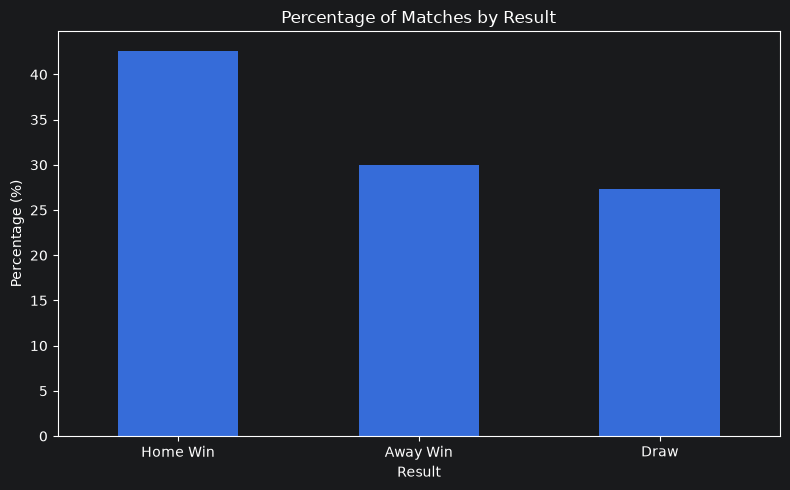

In [9]:
plt.figure(figsize=(8, 5))

result_percentage_display.plot(kind="bar")

plt.title("Percentage of Matches by Result")
plt.xlabel("Result")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Goal Analysis

We now investigate how many goals were scored per match.

This helps us understand the scoring distribution of the season.

In [10]:
goal_distribution = (
    df["TotalGoals"]
    .value_counts()
    .sort_index()
)

goal_distribution

TotalGoals
0     27
1     53
2     91
3    101
4     59
5     33
6      9
7      5
8      1
9      1
Name: count, dtype: int64

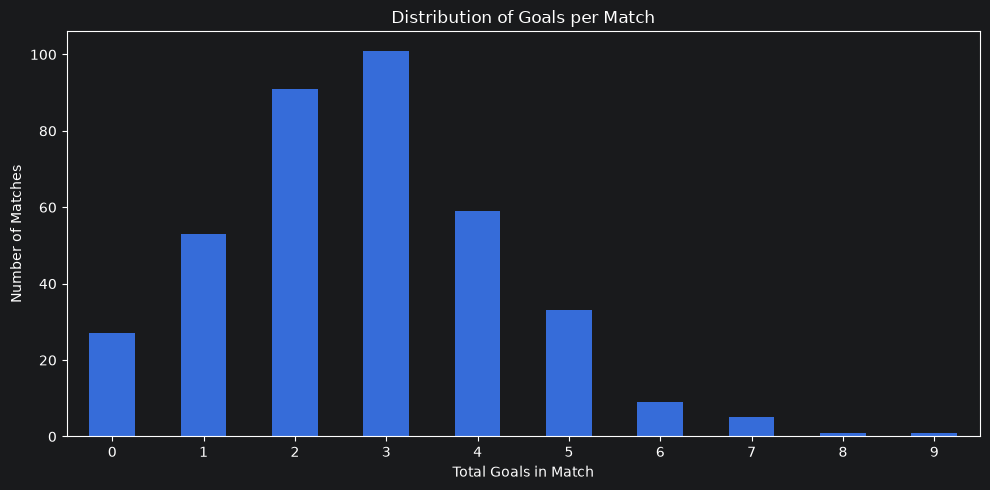

In [11]:
plt.figure(figsize=(10, 5))

goal_distribution.plot(kind="bar")

plt.title("Distribution of Goals per Match")
plt.xlabel("Total Goals in Match")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
print("Total goals:", df["TotalGoals"].sum())
print("Average home goals:", round(df["FTHG"].mean(), 2))
print("Average away goals:", round(df["FTAG"].mean(), 2))
print("Average goals per match:", round(df["TotalGoals"].mean(), 2))

Total goals: 1045
Average home goals: 1.53
Average away goals: 1.22
Average goals per match: 2.75


Home Vs Away Goals

In [13]:
home_goals = df["FTHG"].sum()
away_goals = df["FTAG"].sum()

print("Home goals:", home_goals)
print("Away goals:", away_goals)

Home goals: 580
Away goals: 465


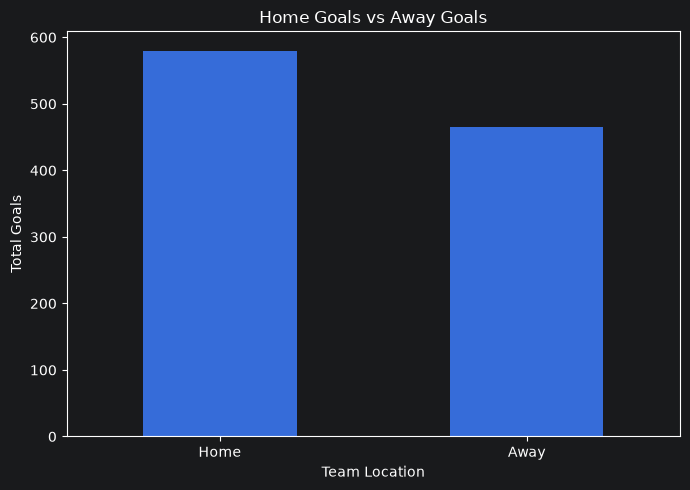

In [14]:
goals = pd.Series({
    "Home": home_goals,
    "Away": away_goals
})

plt.figure(figsize=(7, 5))

goals.plot(kind="bar")

plt.title("Home Goals vs Away Goals")
plt.xlabel("Team Location")
plt.ylabel("Total Goals")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 7. Goals Throughout the Season

We examine how cumulative goals changed throughout the season.

A cumulative plot helps us see the overall progression of scoring across the season.

In [20]:
df = df.sort_values("Date")

df["CumulativeGoals"] = df["TotalGoals"].cumsum()

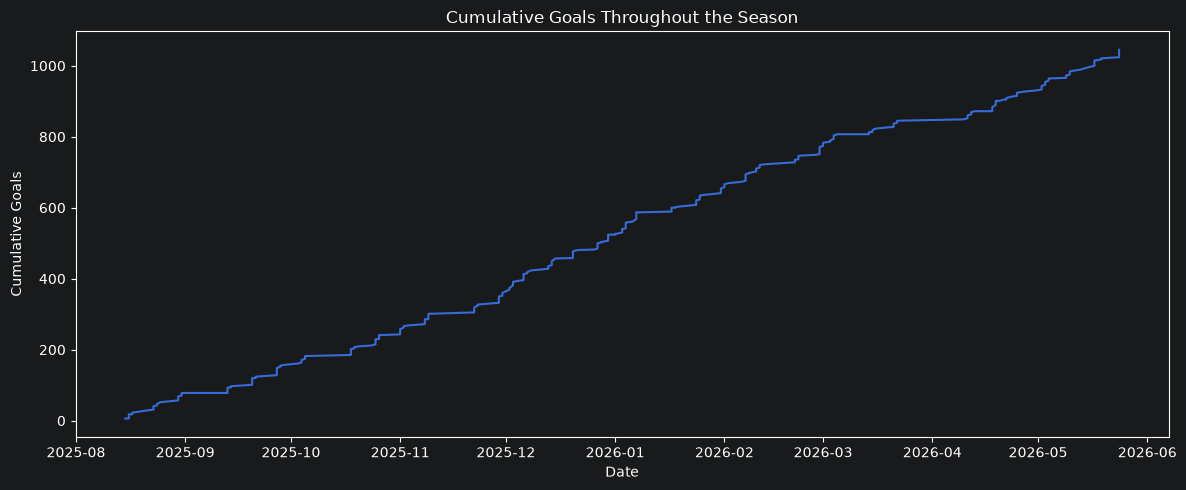

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["CumulativeGoals"]
)

plt.title("Cumulative Goals Throughout the Season")
plt.xlabel("Date")
plt.ylabel("Cumulative Goals")

plt.tight_layout()
plt.show()

## 8. Team Goal Scoring

We calculate total goals scored by each team.

A team can score goals either:

- At home → `FTHG`
- Away → `FTAG`

Therefore, we combine both values.

In [22]:
home_goals_by_team = (
    df.groupby("HomeTeam")["FTHG"]
    .sum()
)

away_goals_by_team = (
    df.groupby("AwayTeam")["FTAG"]
    .sum()
)

team_goals = (
    home_goals_by_team
    .add(away_goals_by_team, fill_value=0)
    .sort_values(ascending=False)
)

team_goals

HomeTeam
Man City          77
Arsenal           71
Man United        69
Liverpool         63
Bournemouth       58
Chelsea           58
Aston Villa       56
Brentford         55
Newcastle         53
Brighton          52
Leeds             49
Nott'm Forest     48
Tottenham         48
Fulham            47
Everton           47
West Ham          46
Sunderland        42
Crystal Palace    41
Burnley           38
Wolves            27
dtype: int64

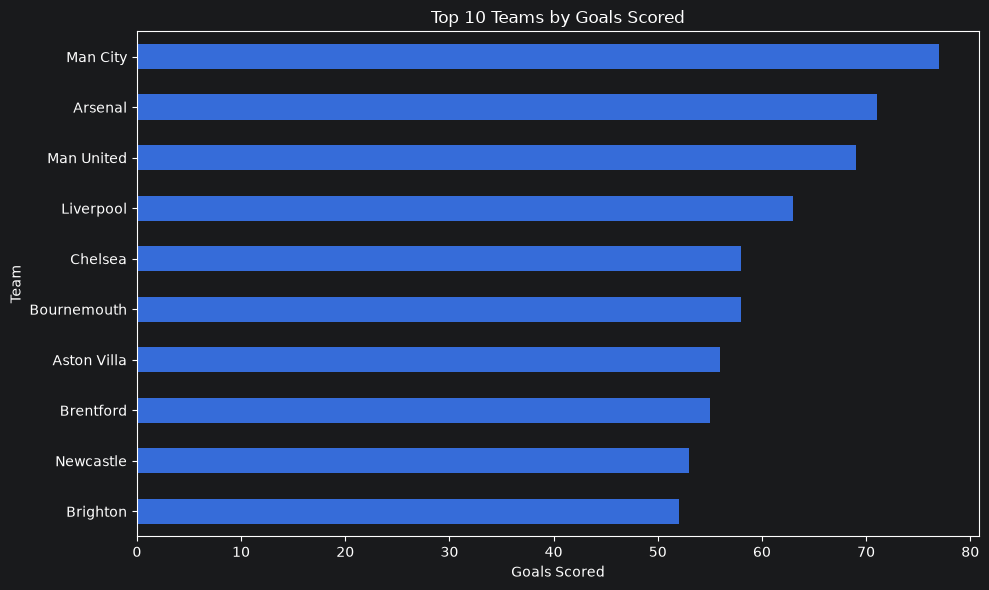

In [23]:
plt.figure(figsize=(10, 6))

team_goals.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Teams by Goals Scored")
plt.xlabel("Goals Scored")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

## 9. Team Goals Conceded

We calculate the total goals conceded by each team.

When playing at home:

`Goals conceded = FTAG`

When playing away:

`Goals conceded = FTHG`

In [24]:
home_conceded = (
    df.groupby("HomeTeam")["FTAG"]
    .sum()
)

away_conceded = (
    df.groupby("AwayTeam")["FTHG"]
    .sum()
)

team_conceded = (
    home_conceded
    .add(away_conceded, fill_value=0)
    .sort_values()
)

team_conceded

HomeTeam
Arsenal           27
Man City          35
Brighton          46
Sunderland        48
Aston Villa       49
Everton           50
Man United        50
Fulham            51
Nott'm Forest     51
Crystal Palace    51
Brentford         52
Chelsea           52
Liverpool         53
Bournemouth       54
Newcastle         55
Leeds             56
Tottenham         57
West Ham          65
Wolves            68
Burnley           75
dtype: int64

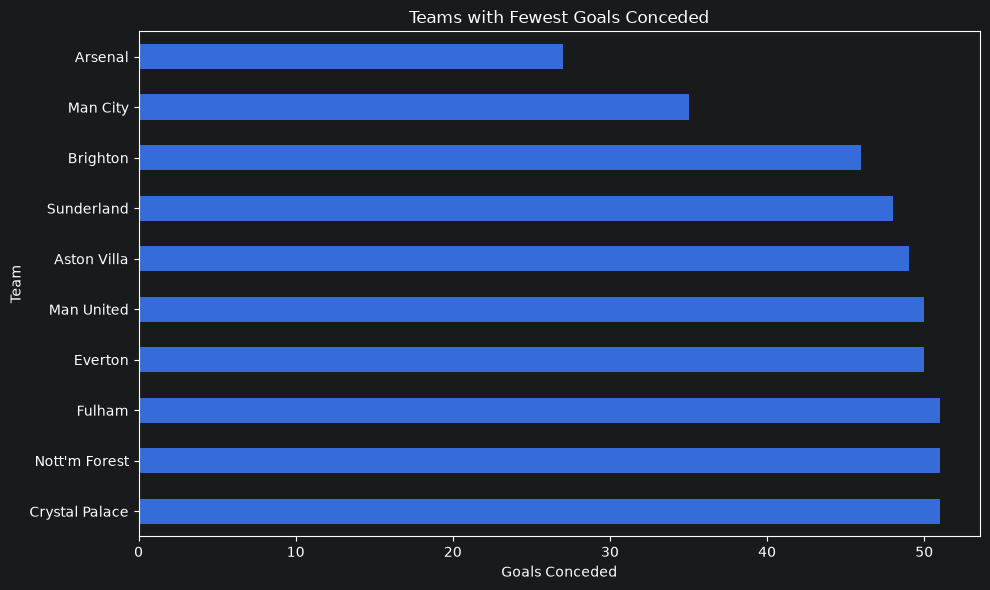

In [25]:
plt.figure(figsize=(10, 6))

team_conceded.head(10).sort_values(ascending=False).plot(
    kind="barh"
)

plt.title("Teams with Fewest Goals Conceded")
plt.xlabel("Goals Conceded")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

## 10. Team Wins

We calculate total wins for each team.

A home team wins when:

`FTR = H`

An away team wins when:

`FTR = A`

In [26]:
home_wins = (
    df[df["FTR"] == "H"]
    .groupby("HomeTeam")
    .size()
)

away_wins = (
    df[df["FTR"] == "A"]
    .groupby("AwayTeam")
    .size()
)

team_wins = (
    home_wins
    .add(away_wins, fill_value=0)
    .sort_values(ascending=False)
)

team_wins

HomeTeam
Arsenal           26.0
Man City          23.0
Man United        20.0
Aston Villa       19.0
Liverpool         17.0
Fulham            15.0
Sunderland        14.0
Brentford         14.0
Brighton          14.0
Newcastle         14.0
Chelsea           14.0
Bournemouth       13.0
Everton           13.0
Nott'm Forest     11.0
Crystal Palace    11.0
Leeds             11.0
West Ham          10.0
Tottenham         10.0
Burnley            4.0
Wolves             3.0
dtype: float64

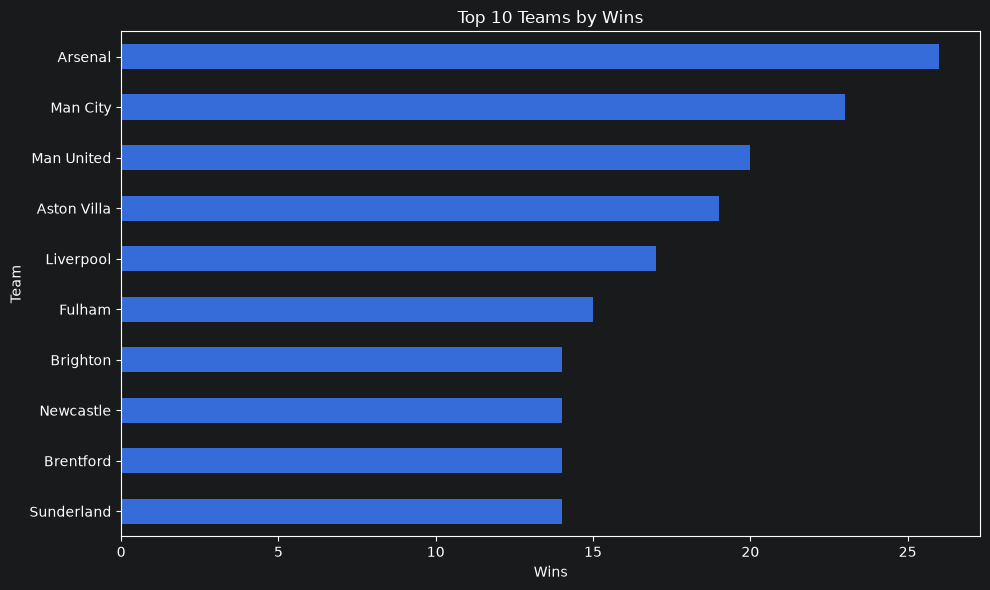

In [27]:
plt.figure(figsize=(10, 6))

team_wins.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Teams by Wins")
plt.xlabel("Wins")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

## 11. Team Performance Summary

We combine goals scored, goals conceded and wins into a single team-level summary.

In [28]:
team_summary = pd.DataFrame({
    "Goals Scored": team_goals,
    "Goals Conceded": team_conceded,
    "Wins": team_wins
})

team_summary["Goal Difference"] = (
    team_summary["Goals Scored"]
    - team_summary["Goals Conceded"]
)

team_summary = team_summary.sort_values(
    "Wins",
    ascending=False
)

team_summary

,Goals Scored,Goals Conceded,Wins,Goal Difference
HomeTeam,,,,
Arsenal,71,27,26.0,44
Man City,77,35,23.0,42
Man United,69,50,20.0,19
Aston Villa,56,49,19.0,7
Liverpool,63,53,17.0,10
Fulham,47,51,15.0,-4
Sunderland,42,48,14.0,-6
Brentford,55,52,14.0,3
Brighton,52,46,14.0,6


## 12. Shooting Analysis

The dataset contains:

- `HS` → Home shots
- `AS` → Away shots
- `HST` → Home shots on target
- `AST` → Away shots on target

We investigate whether shooting activity is associated with goals.

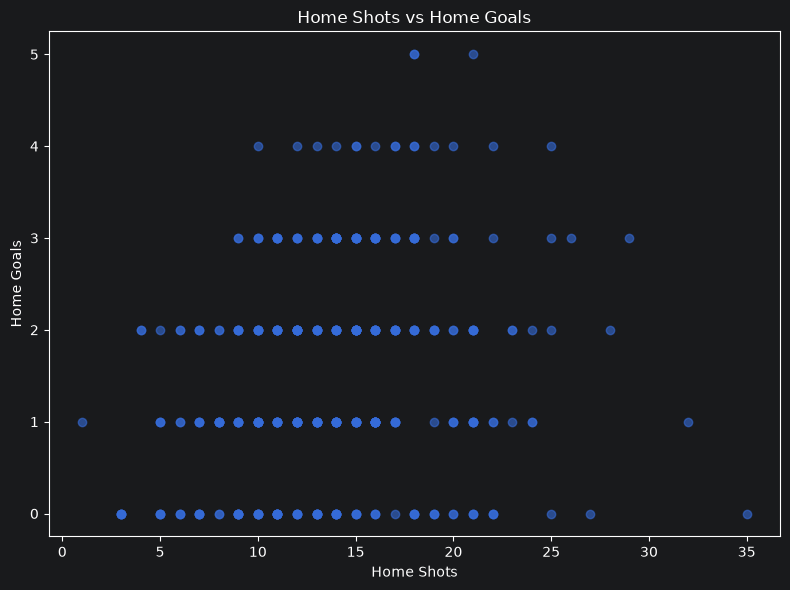

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["HS"],
    df["FTHG"],
    alpha=0.6
)

plt.title("Home Shots vs Home Goals")
plt.xlabel("Home Shots")
plt.ylabel("Home Goals")

plt.tight_layout()
plt.show()

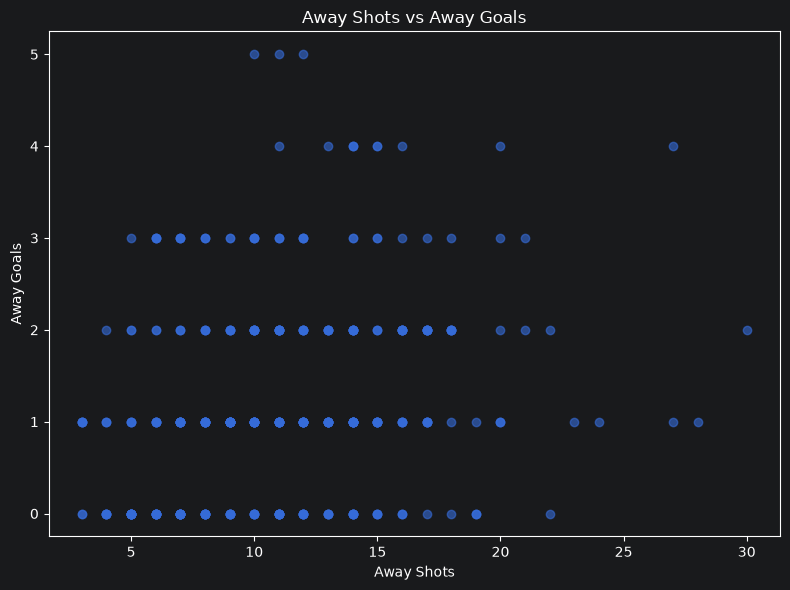

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["AS"],
    df["FTAG"],
    alpha=0.6
)

plt.title("Away Shots vs Away Goals")
plt.xlabel("Away Shots")
plt.ylabel("Away Goals")

plt.tight_layout()
plt.show()

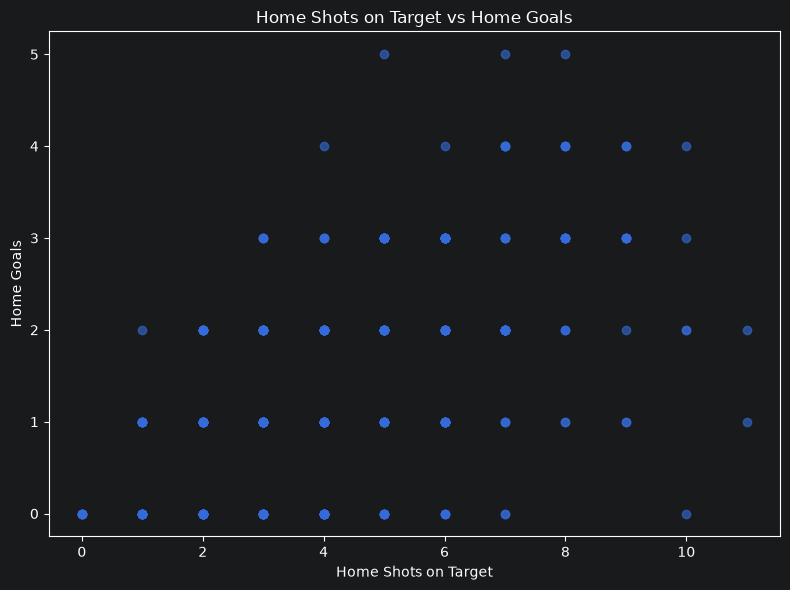

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["HST"],
    df["FTHG"],
    alpha=0.6
)

plt.title("Home Shots on Target vs Home Goals")
plt.xlabel("Home Shots on Target")
plt.ylabel("Home Goals")

plt.tight_layout()
plt.show()

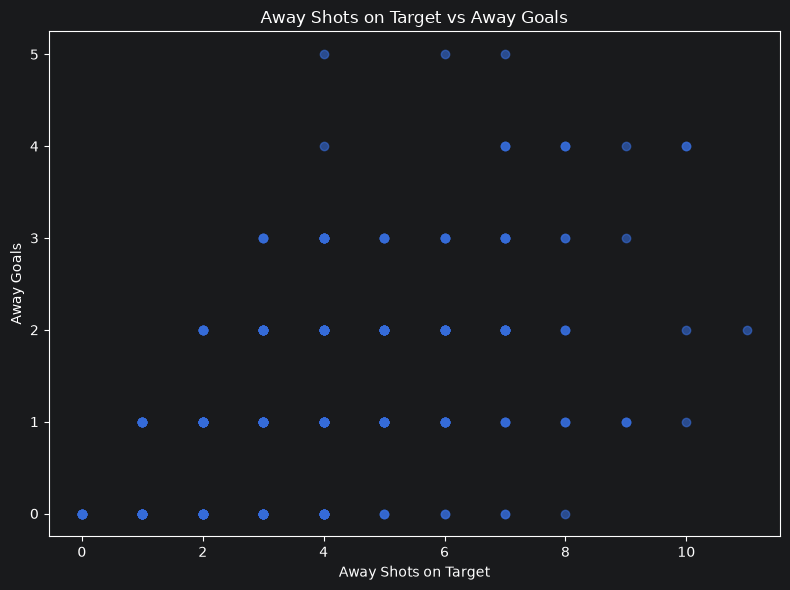

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["AST"],
    df["FTAG"],
    alpha=0.6
)

plt.title("Away Shots on Target vs Away Goals")
plt.xlabel("Away Shots on Target")
plt.ylabel("Away Goals")

plt.tight_layout()
plt.show()

## 13. Correlation Analysis

Correlation measures the strength and direction of a linear relationship between numerical variables.

A correlation close to:

- `+1` → strong positive relationship
- `0` → little or no linear relationship
- `-1` → strong negative relationship

Correlation does not imply causation.

In [33]:
football_stats = [
    "FTHG", "FTAG",
    "HS", "AS",
    "HST", "AST",
    "HF", "AF",
    "HC", "AC",
    "HY", "AY",
    "HR", "AR"
]

correlation = df[football_stats].corr()

correlation

,FTHG,FTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
FTHG,1.000000,-0.030639,0.218327,-7.820428e-02,0.567241,-0.063226,-0.071915,0.016667,-0.020616,0.024185,-0.011299,0.064479,-1.028525e-01,0.024951
FTAG,-0.030639,1.000000,-0.052270,2.423043e-01,-0.033297,0.541215,0.078316,-0.101029,0.026245,0.068830,0.109648,-0.060774,8.823537e-02,-0.070423
HS,0.218327,-0.052270,1.000000,-3.469734e-01,0.608988,-0.197104,-0.073485,0.061417,0.500305,-0.344154,-0.041374,0.047313,-6.398751e-02,0.131643
AS,-0.078204,0.242304,-0.346973,1.000000e+00,-0.222408,0.623294,0.034603,-0.157497,-0.284487,0.496001,0.028189,-0.145275,9.659785e-18,-0.077819
HST,0.567241,-0.033297,0.608988,-2.224084e-01,1.000000,-0.142704,-0.047772,0.056066,0.237191,-0.177559,-0.026941,0.068160,-6.604384e-02,0.089110
AST,-0.063226,0.541215,-0.197104,6.232944e-01,-0.142704,1.000000,0.080807,-0.062336,-0.143577,0.257502,0.062634,-0.115630,3.340600e-02,-0.041463
HF,-0.071915,0.078316,-0.073485,3.460350e-02,-0.047772,0.080807,1.000000,0.146773,-0.086567,-0.066418,0.313052,0.069584,1.007041e-01,0.095231
AF,0.016667,-0.101029,0.061417,-1.574975e-01,0.056066,-0.062336,0.146773,1.000000,0.047123,-0.188652,0.109107,0.399699,1.197847e-01,0.087573
HC,-0.020616,0.026245,0.500305,-2.844870e-01,0.237191,-0.143577,-0.086567,0.047123,1.000000,-0.288936,-0.044733,-0.022178,-3.006199e-02,0.130175
AC,0.024185,0.068830,-0.344154,4.960013e-01,-0.177559,0.257502,-0.066418,-0.188652,-0.288936,1.000000,0.016819,-0.079883,2.606913e-02,-0.047455


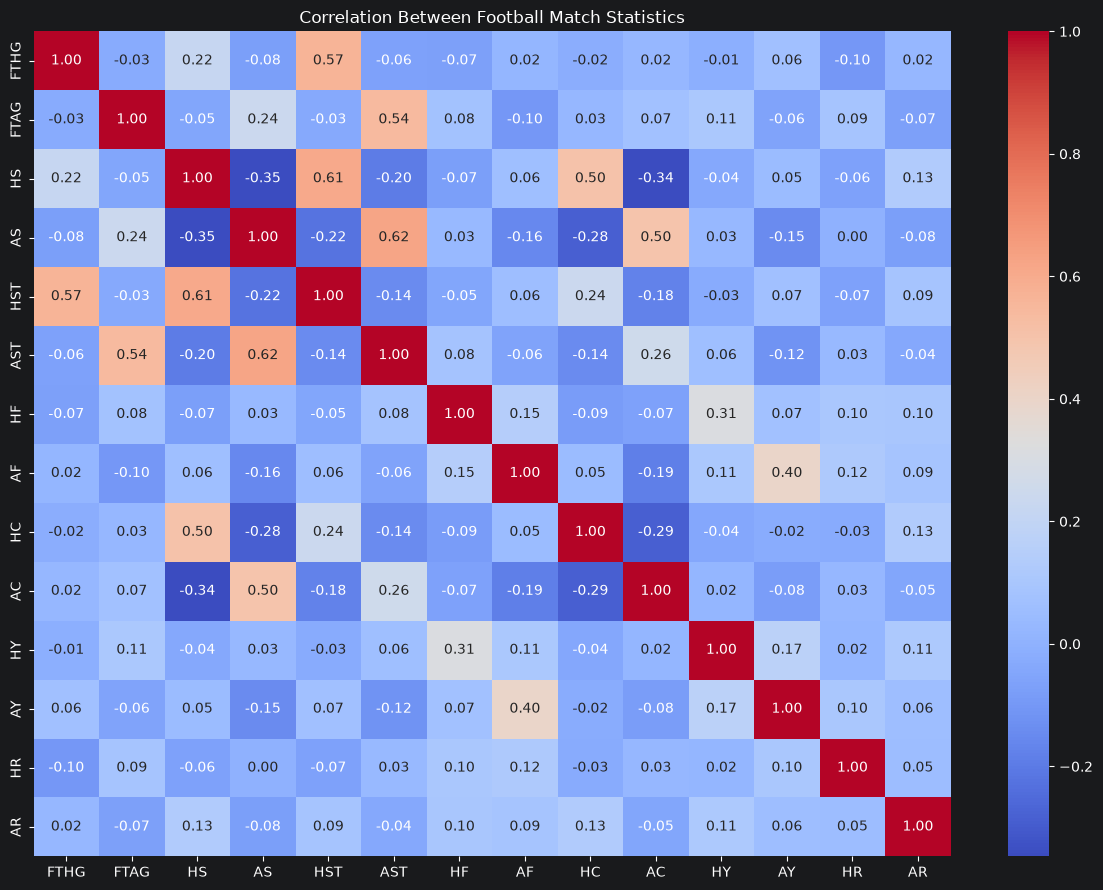

In [34]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Football Match Statistics")

plt.tight_layout()
plt.show()

## 14. Highest-Scoring Matches
We identify matches with the highest total number of goals.

In [35]:
highest_scoring_matches = (
    df.sort_values(
        "TotalGoals",
        ascending=False
    )
)

highest_scoring_matches[
    [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
        "TotalGoals"
    ]
].head(10)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,TotalGoals
131,2025-12-02,Fulham,Man City,4,5,9
159,2025-12-15,Man United,Bournemouth,4,4,8
274,2026-02-28,Liverpool,West Ham,5,2,7
273,2026-02-28,Burnley,Brentford,3,4,7
208,2026-01-07,Newcastle,Leeds,4,3,7
134,2025-12-03,Brighton,Aston Villa,3,4,7
324,2026-04-19,Aston Villa,Sunderland,4,3,7
83,2025-10-25,Man United,Brighton,4,2,6
54,2025-09-27,Man City,Burnley,5,1,6
195,2026-01-04,Everton,Brentford,2,4,6


## 15. Biggest Wins

We identify matches with the largest absolute goal difference.

In [36]:
biggest_wins = (
    df.sort_values(
        "GoalDifference",
        key=lambda x: x.abs(),
        ascending=False
    )
)

biggest_wins[
    [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
        "GoalDifference"
    ]
].head(10)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,GoalDifference
332,2026-04-24,Sunderland,Nott'm Forest,0,5,-5
15,2025-08-23,Arsenal,Leeds,5,0,5
10,2025-08-22,West Ham,Chelsea,1,5,-4
309,2026-04-10,West Ham,Wolves,4,0,4
54,2025-09-27,Man City,Burnley,5,1,4
105,2025-11-09,Aston Villa,Bournemouth,4,0,4
231,2026-01-31,Leeds,Arsenal,0,4,-4
5,2025-08-16,Wolves,Man City,0,4,-4
30,2025-09-13,Arsenal,Nott'm Forest,3,0,3
343,2026-05-02,Arsenal,Fulham,3,0,3


# EDA Findings

After examining the visualizations and statistics, record the important findings from the dataset.

Possible areas to discuss:

- Distribution of home wins, draws and away wins
- Average goals per match
- Difference between home and away goals
- Highest-scoring teams
- Teams conceding the fewest goals
- Relationship between shots and goals
- Relationship between shots on target and goals
- Any interesting match-level patterns

Only record findings that are actually supported by the results of this dataset.

In [37]:
print("===== EDA SUMMARY =====")

print("\nTotal matches:", len(df))

print(
    "Average goals per match:",
    round(df["TotalGoals"].mean(), 2)
)

print(
    "Home goals:",
    df["FTHG"].sum()
)

print(
    "Away goals:",
    df["FTAG"].sum()
)

print(
    "Most successful team by wins:",
    team_wins.index[0],
    "with",
    int(team_wins.iloc[0]),
    "wins"
)

print(
    "Top scoring team:",
    team_goals.index[0],
    "with",
    int(team_goals.iloc[0]),
    "goals"
)

===== EDA SUMMARY =====

Total matches: 380
Average goals per match: 2.75
Home goals: 580
Away goals: 465
Most successful team by wins: Arsenal with 26 wins
Top scoring team: Man City with 77 goals
